# Twitter Hate Speech Detection — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (24783, 2)


,tweet,class_name
0,!!! RT @mayasolovely: As a woman you shouldn't...,neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['tweet', 'class_name']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0
Duplicates: 0
After cleanup: (24783, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['tweet'].iloc[0][:300]))
df['clean_text'] = df['tweet'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
"!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out..."



Example AFTER:
'rt mayasolov woman complain clean hous amp man alway take trash'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 0 rows that were empty after cleaning
Remaining: 24783


## 5. Cleaned Text Length Comparison

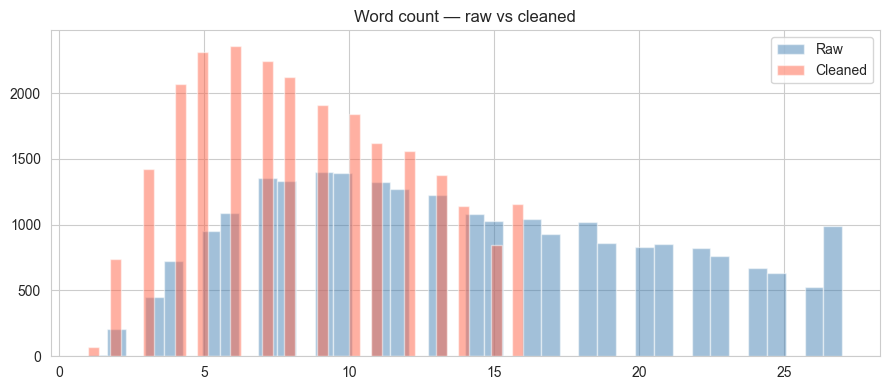

Mean words raw : 14.1
Mean words clean: 8.5


In [6]:
df['raw_words'] = df['tweet'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# Map label to integer codes
df['label'] = df['class_name'].astype('category')
label_mapping = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes
print('Label mapping:', label_mapping)

Label mapping: {0: 'hate_speech', 1: 'neither', 2: 'offensive'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/hate_speech_cleaned.csv', index=False)
print('Saved -> data/hate_speech_cleaned.csv', out.shape)
out.head()

Saved -> data/hate_speech_cleaned.csv (24783, 2)


,clean_text,label
0,rt mayasolov woman complain clean hous amp man...,1
1,rt mleew boy dat cold tyga dwn bad cuffin dat ...,2
2,rt urkindofbrand dawg rt sbabi life ever fuck ...,2
3,rt anderson viva base look like tranni,2
4,rt shenikarobert shit hear might true might fa...,2
